# 02 · Stacking Layers

> **Series:** How a Convolutional Neural Network Learns
> **Prerequisites:** notebook 01
> **Renders to:** `results/02_stack_forward.gif`, `results/02_maxpool_sweep.gif`,
> portrait cuts of both as `…_feed.gif` + `…_feed.mp4`, and the stills
> `results/02_linear_collapse.png`, `results/02_relu_gate.png`,
> `results/02_threshold.png`, `results/02_receptive_field.png`

Notebook 01 took a single kernel and watched it turn a digit into one feature
map. A real convolutional network stacks that operation: the output of one
convolution becomes the input of the next, with a ReLU between them and
usually a pooling step as well.

This notebook is about what each of those additions actually buys. It starts
with the one that buys **nothing at all**.

## 1. Setup

Same opening as every notebook in the series: import `cnnviz`, apply the
shared visual style, fix a seed.

Theme and language are switches rather than rewrites. Every label baked into a
figure comes from `cnnviz.text`, so `set_language("pt-BR")` re-renders the whole
notebook in Portuguese — decimal separators included — without a line of the
explanation around it changing.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from cnnviz import animate, formats, panels, results, style, text
from cnnviz.data import load_mnist
from cnnviz.layers import (
    Conv2D,
    MaxPool2D,
    ReLU,
    Sequential,
    receptive_field,
    trace_receptive_field,
)

style.use_project_style(theme="dark")
text.set_language("en")

RNG = np.random.default_rng(0)
NOTEBOOK = 2

## 2. The input

The same `7` as notebook 01, unnormalised, but this time the whole
$28 \times 28$ digit rather than a crop. We are no longer annotating
individual cells, so the full image costs nothing — and the digit needs to be
large enough that a second layer has something to pool away.

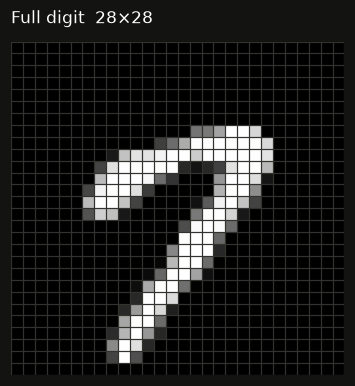

In [2]:
images, labels = load_mnist(train=True, normalize=False)

digit = images[np.flatnonzero(labels == 7)[0], 0]   # (28, 28)
x = digit[None, None]                               # (N, C, H, W), as layers expect

fig, ax = plt.subplots(figsize=(3.2, 3.4))
panels.draw_matrix(ax, digit, mode="pixels", title=f"{text.t('full_digit')}  28×28")
plt.show()

## 3. Depth without a nonlinearity is not depth

Here is the claim that motivates everything else in this notebook.

**Two convolutions applied one after the other are a single convolution.** Not
approximately — exactly. Convolution is linear, and a composition of linear
maps is a linear map, so there is always one kernel that does the job of the
pair. For a $3 \times 3$ kernel $A$ followed by a $3 \times 3$ kernel $B$, the
single equivalent kernel is $5 \times 5$:

$$
C_{a,b} \;=\; \sum_{u + p \,=\, a} \; \sum_{v + q \,=\, b} B_{u,v} \, A_{p,q}
$$

which is the *full convolution* of $A$ with $B$. Read the code below instead of
the formula: each cell of $B$ drops a scaled copy of $A$ into $C$, offset by
that cell's position.

So a network of stacked convolutions and nothing else has the representational
power of one convolution, however many layers you give it. Depth is free
parameters and no new expressiveness.

In [3]:
A = RNG.normal(0, 0.4, size=(3, 3)).astype(np.float32)
B = RNG.normal(0, 0.4, size=(3, 3)).astype(np.float32)


def conv_with(kernel):
    """A single-channel Conv2D carrying a kernel we chose, and no bias."""
    layer = Conv2D(1, 1, kernel_size=kernel.shape[0], seed=0)
    layer.W = kernel[None, None].astype(np.float32)
    layer.b = np.zeros(1, dtype=np.float32)
    return layer


stacked = conv_with(B).forward(conv_with(A).forward(x))[0, 0]

# Each cell of B places a scaled copy of A, offset by that cell's position.
C = np.zeros((5, 5), dtype=np.float32)
for (u, v), weight in np.ndenumerate(B):
    C[u:u + 3, v:v + 3] += weight * A

single = conv_with(C).forward(x)[0, 0]

print(f"A → B stacked   {stacked.shape}")
print(f"one 5×5 kernel  {single.shape}")
print(f"largest difference   {np.abs(stacked - single).max():.2e}   (float32 rounding)")

A → B stacked   (24, 24)
one 5×5 kernel  (24, 24)
largest difference   2.38e-07   (float32 rounding)


Now put a ReLU between the two convolutions and repeat. The equality that held
exactly a moment ago breaks, and not by a rounding error: the gap is a
substantial fraction of the map's own range.

It breaks permanently, too. No kernel at all can reproduce the gated version,
whatever its size — a convolution is a linear map, and the composition is no
longer linear. That is the whole reason the nonlinearity is there.

In [4]:
gated = conv_with(B).forward(ReLU().forward(conv_with(A).forward(x)))[0, 0]

print(f"with a ReLU between them   {np.abs(gated - single).max():.3f}")
print(f"for scale, |output| max    {np.abs(single).max():.3f}")

with a ReLU between them   0.280
for scale, |output| max    2.334


The figure below is the same statement drawn. Note the scale on the bottom
row: **all three panels share one colour scale**, taken from the two outputs.
Given its own scale, a difference map holding nothing but float32 rounding
noise would render as a vivid pattern and appear to contradict the number
printed in its title. This is notebook 01's animation trap in still form.

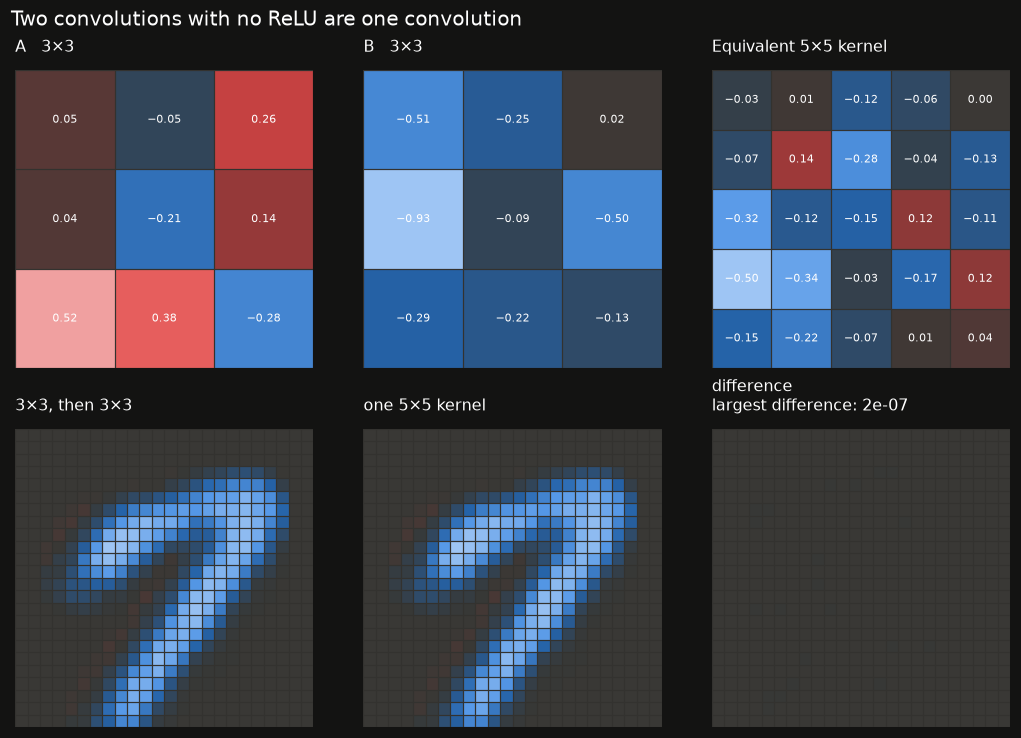

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(9.5, 6.6))

for ax, kernel, title in zip(
    axes[0], (A, B, C),
    ("A   3×3", "B   3×3", text.t("collapse_equivalent")),
):
    panels.draw_matrix(ax, kernel, mode="signed", annotate=True, fontsize=7.5,
                       title=title, title_fontsize=10.5)

difference = stacked - single
shared = style.signed_norm(np.stack([stacked, single]), robust=False)
largest = text.t("largest_difference", v=f"{np.abs(difference).max():.0e}")

for ax, values, title in zip(
    axes[1], (stacked, single, difference),
    (text.t("collapse_stacked"), text.t("collapse_single"),
     f"{text.t('collapse_diff')}\n{largest}"),
):
    panels.draw_matrix(ax, values, mode="signed", norm=shared, title=title,
                       title_fontsize=10.5)

fig.suptitle(text.t("collapse_title"), x=0.02, ha="left")
fig.savefig(results.output_path("linear_collapse.png", notebook=NOTEBOOK), dpi=140)
plt.show()

## 4. A layer is a bank of kernels

One kernel answers one question. A convolutional layer runs several in
parallel over the same input, producing one feature map per kernel — the
*channels* of the output.

We hand-design four of them, as in notebook 01, so that everything below is
interpretable before anything is learned. Each is a **derivative of a
Gaussian** taken along one direction:

$$
w(u, v) \;=\; \bigl(v \cos\theta + u \sin\theta\bigr)\,
              e^{-\frac{u^2 + v^2}{2\sigma^2}}
$$

At $\theta = 0^\circ$ the weights climb from left to right, so the kernel
measures horizontal change and fires on **vertical** edges — the Sobel kernel
of notebook 01, smoothed. At $\theta = 90^\circ$ it fires on horizontal edges.
The Gaussian factor is what makes it a *local* measurement rather than a noisy
one.

Two normalisations, both load-bearing:

- **Subtract the mean**, so a flat patch scores exactly zero. Without this a
  bright flat region would produce a response and the map would read as an
  edge where there is none.
- **Divide by the sum of the positive weights**, so a full black-to-white step
  scores exactly $1.0$. That makes the numbers in every later panel
  interpretable as a fraction of maximum contrast rather than arbitrary units.

We do not annotate these kernels cell by cell. With a hand-built Sobel the
integers were the point; here the individual weights of a sampled Gaussian
derivative mean nothing on their own, and 25 numbers per panel would only
crowd out the structure.

In [6]:
def oriented_edge(degrees, size=5, sigma=1.2):
    """A `size`×`size` edge detector for edges running at `degrees`."""
    r = np.arange(size) - size // 2
    u, v = np.meshgrid(r, r, indexing="ij")     # u down the rows, v across the columns
    theta = np.radians(degrees)

    w = (v * np.cos(theta) + u * np.sin(theta))
    w = w * np.exp(-(u ** 2 + v ** 2) / (2 * sigma ** 2))
    w -= w.mean()                # a flat patch scores exactly zero
    return (w / w[w > 0].sum()).astype(np.float32)   # a full black→white step scores 1.0


ANGLES = (0, 45, 90, 135)

# padding=2 keeps the output 28×28: with a 5×5 kernel, p = ⌊K/2⌋ is the value
# that preserves the input size, so the shape ladder only shrinks where we
# actually ask it to — at the pooling layers.
conv1 = Conv2D(1, 4, kernel_size=5, padding=2, seed=0)
conv1.W = np.stack([oriented_edge(a) for a in ANGLES])[:, None]
conv1.b = np.zeros(4, dtype=np.float32)

pre1 = conv1.forward(x)
print(f"input {x.shape[1:]} → pre-activation {pre1.shape[1:]}")
print(f"range [{pre1.min():+.3f}, {pre1.max():+.3f}]")

input (1, 28, 28) → pre-activation (4, 28, 28)
range [-0.973, +0.988]


Both rows below share one colour scale *across channels*, which is the whole
point of a contact sheet: it lets you see that the $45^\circ$ kernel responds
more strongly to this digit than the $135^\circ$ one. Scaled per panel, every
channel would look equally busy and the comparison would be destroyed.

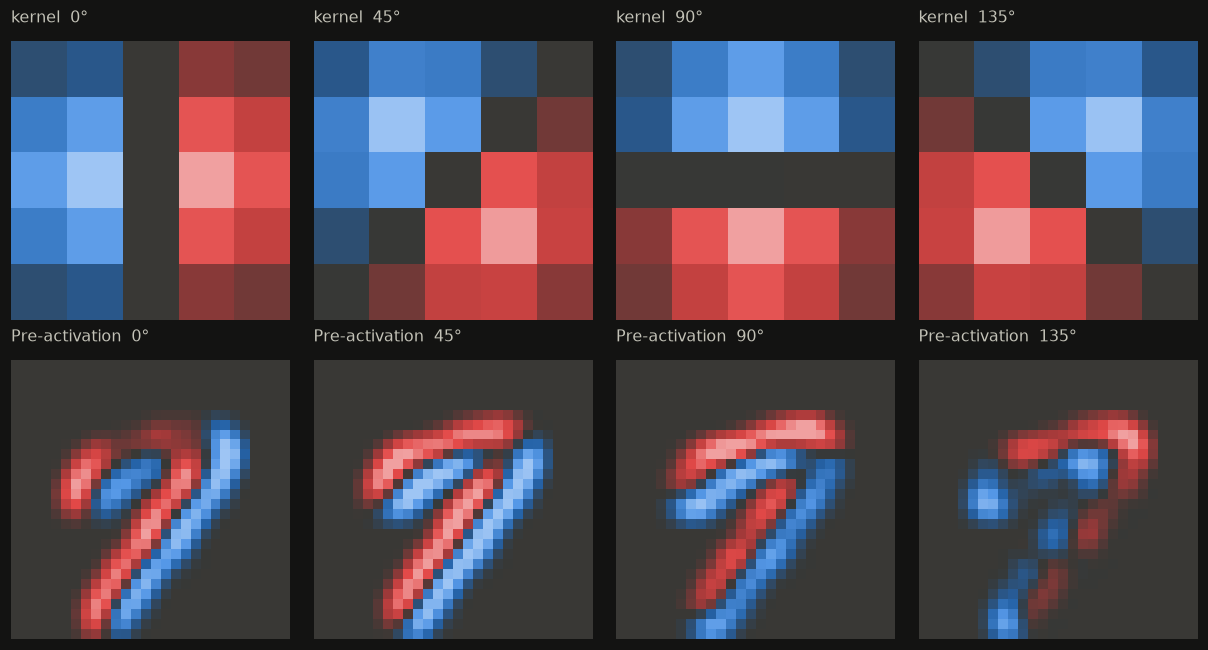

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(11, 5.8))

panels.draw_maps(
    axes[0], conv1.W[:, 0], mode="signed",
    titles=[f"{text.t('kernel')}  {a}°" for a in ANGLES], title_fontsize=10.5,
)
panels.draw_maps(
    axes[1], pre1[0], mode="signed",
    titles=[f"{text.t('pre_activation')}  {a}°" for a in ANGLES], title_fontsize=10.5,
)
plt.show()

## 5. ReLU, the gate

$f(x) = \max(0, x)$ is the entire operation. Two consequences worth seeing
rather than reading.

**It changes what the numbers are.** A pre-activation is signed: negative
means "an edge, the other way round". After a ReLU nothing is negative, and
the quantity has become a magnitude — "how much of this feature is here". That
is why the encoding changes between the panels below, from the diverging ramp
to the sequential one. The colour follows the data, not the layer's position.

**It throws away most of the map.** The cell below counts why. Part of what
the gate closes on is *genuinely negative* — an edge running the other way,
which the kernel scored below zero and the ReLU discards outright. Nothing
downstream can recover it, so a network that needs both polarities has to
spend a second kernel on the opposite sign; that is exactly what a trained
first layer does, and notebook 06 opens one up.

The rest is *exactly zero*: the empty margin around the digit, where a
zero-mean kernel on a flat patch returns nothing. That share is an artefact of
MNIST's generous padding rather than a fact about ReLU, which is why it is
worth separating the two numbers instead of quoting one.

gate closed on   78.8% of cells
  negative       21.6%   an edge the other way round
  exactly zero   57.3%   the flat margin around the digit


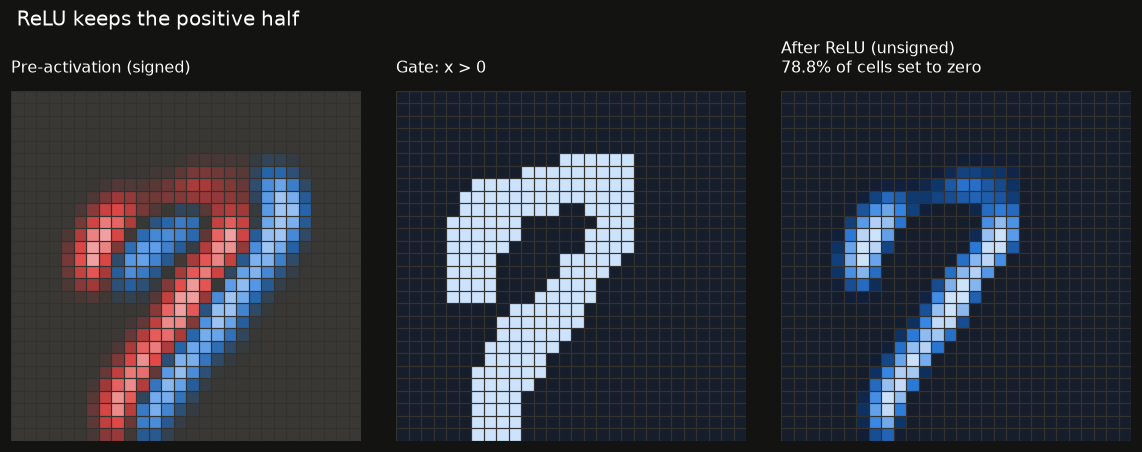

In [8]:
act1 = ReLU().forward(pre1)

zeroed = float((pre1 <= 0).mean() * 100)
negative = float((pre1 < 0).mean() * 100)
flat = float((pre1 == 0).mean() * 100)
print(f"gate closed on   {zeroed:.1f}% of cells")
print(f"  negative       {negative:.1f}%   an edge the other way round")
print(f"  exactly zero   {flat:.1f}%   the flat margin around the digit")

channel = 0                     # the 0° kernel: vertical edges
gate = (pre1[0, channel] > 0).astype(np.float32)

fig, axes = plt.subplots(1, 3, figsize=(10.5, 4.0))
panels.draw_matrix(axes[0], pre1[0, channel], mode="signed",
                   title=text.t("relu_pre"), title_fontsize=10.5)
panels.draw_matrix(axes[1], gate, mode="magnitude",
                   title=text.t("relu_gate"), title_fontsize=10.5)
panels.draw_matrix(axes[2], act1[0, channel], mode="magnitude",
                   title=f"{text.t('relu_post')}\n"
                         f"{text.t('relu_zeroed', p=text.num(zeroed, 1))}",
                   title_fontsize=10.5)

fig.suptitle(text.t("relu_title"), x=0.02, ha="left")
fig.savefig(results.output_path("relu_gate.png", notebook=NOTEBOOK), dpi=140)
plt.show()

The middle panel is the mask the backward pass will use: gradient flows where
it is bright and is blocked where it is pale. It is worth remembering the
shape of it, because notebook 08 shows what happens to a unit whose mask goes
dark everywhere and stays that way.

## 6. Max pooling

Pooling replaces each non-overlapping $2 \times 2$ window with its largest
value. The map halves in both dimensions, so three quarters of the numbers are
discarded.

The animation is the same grammar as notebook 01's sweep — a window moving
over an input, one number produced per stop — because the reader has already
learned to read that. What is different is what happens inside the window: no
arithmetic, just a comparison, and only the winner survives.

The activation map is cropped to $12 \times 12$ so the four numbers under the
window stay readable. Both matrix panels share one colour scale fixed over the
whole sweep, for the reason notebook 01 laboured: a panel rescaled to its own
frame would render a weak window exactly as vividly as a strong one.

In [9]:
pool = MaxPool2D(2)
pool1 = pool.forward(act1)

crop = act1[0, 0][4:16, 6:18]                          # 12×12 over the digit's strokes
pooled = MaxPool2D(2).forward(crop[None, None])[0, 0]   # 6×6

NORM_ACT = style.magnitude_norm(crop, robust=False)
POSITIONS = [(i, j) for i in range(pooled.shape[0]) for j in range(pooled.shape[1])]

PTOP, PBOTTOM = 0.735, 0.215


def draw_pool(fig, k):
    row, col = POSITIONS[k]
    window = crop[row * 2:row * 2 + 2, col * 2:col * 2 + 2]
    winner = np.unravel_index(np.argmax(window), window.shape)

    gs = GridSpec(
        1, 3, figure=fig, width_ratios=[1.35, 0.55, 1.35],
        left=0.020, right=0.972, top=PTOP, bottom=PBOTTOM, wspace=0.42,
    )
    ax_in, ax_win, ax_out = (fig.add_subplot(gs[0, c]) for c in range(3))

    panels.draw_matrix(ax_in, crop, mode="magnitude", norm=NORM_ACT,
                       title=f"{text.t('activation_map')}   12×12", title_fontsize=10.5)
    panels.highlight_window(ax_in, row * 2, col * 2, size=2)

    panels.draw_matrix(ax_win, window, mode="magnitude", norm=NORM_ACT, annotate=True,
                       fontsize=9.5, title=text.t("pool_window"), title_fontsize=10.5)
    panels.highlight_window(ax_win, winner[0], winner[1], size=1)

    revealed = np.ma.masked_all(pooled.shape, dtype=pooled.dtype)
    revealed.flat[:k + 1] = pooled.flat[:k + 1]
    panels.draw_matrix(ax_out, revealed, mode="magnitude", norm=NORM_ACT,
                       title=f"{text.t('pooled_map')}   6×6", title_fontsize=10.5)
    panels.highlight_window(ax_out, row, col, size=1)

    panels.glyph_between(fig, ax_win, ax_out, "→", y=(PTOP + PBOTTOM) / 2, fontsize=20)
    box = ax_win.get_position()
    fig.text((box.x0 + box.x1) / 2, 0.170,
             text.t("pool_max", v=text.num(float(window.max()), 2)),
             ha="center", va="top", fontsize=12.5, color=style.INK_PRIMARY)

    panels.frame_header(fig, text.t("pool_title"), text.t("pool_subtitle"))
    panels.caption(fig, f"{text.t('position_of', k=k + 1, n=len(POSITIONS))}"
                        f"   ·   {text.t('pool_dropped')}, {text.t('pool_gradient')}")
    panels.progress_bar(fig, (k + 1) / len(POSITIONS))


animate.animate(
    draw_pool,
    n_frames=len(POSITIONS),
    path=results.output_path("maxpool_sweep.gif", notebook=NOTEBOOK),
    figsize=(11.5, 4.3),
    durations=animate.hold_at(len(POSITIONS), fps=9, holds={0: 1.0, 1: 0.6, 2: 0.35}),
)

02_maxpool_sweep:   0%|          | 0/36 [00:00<?, ?frame/s]

PosixPath('/Users/usuario/Desktop/howAIworks/results/02_maxpool_sweep.gif')

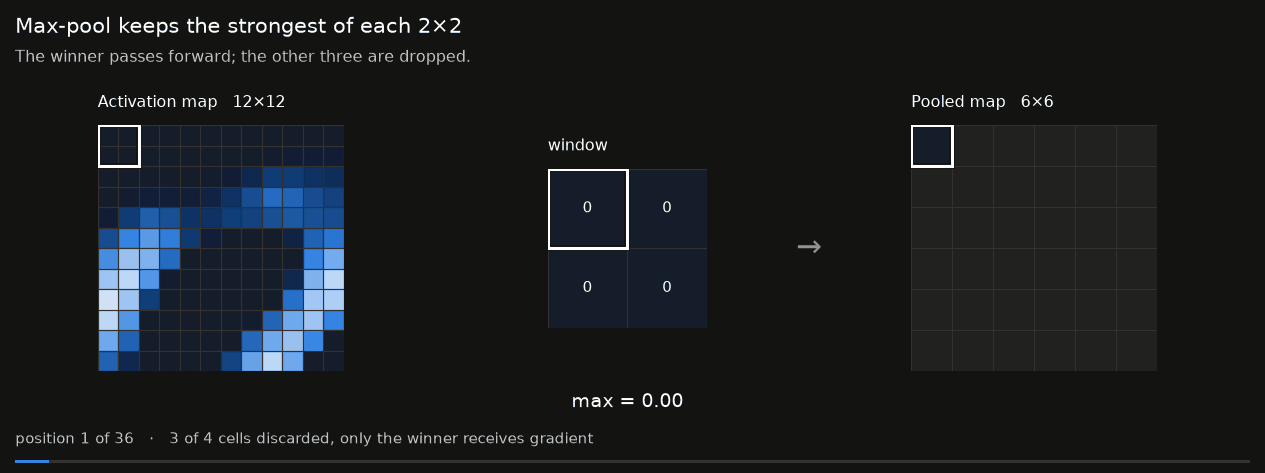

In [10]:
from IPython.display import Image, display

display(Image(filename=str(results.output_path("02_maxpool_sweep.gif"))))

### What pooling is for

The usual justification is cost: halving both dimensions quarters the work of
every layer that follows, and it widens the receptive field, which section 9
makes precise.

The second justification is **tolerance to small shifts**, and it is worth
measuring rather than asserting. Shift the digit by one pixel and compare the
layer-1 output before and after, against the same comparison for the pooled
map. A third row is the honest control: plain subsampling, taking every other
cell, which downsamples by the same factor but keeps whichever value happens
to land on the grid.

In [11]:
def edges_then_pool(image):
    """conv1 → ReLU → max-pool on one image; returns both stages."""
    activation = ReLU().forward(conv1.forward(image[None, None]))
    return activation[0], MaxPool2D(2).forward(activation)[0]


act_o, pool_o = edges_then_pool(digit)
act_s, pool_s = edges_then_pool(np.roll(digit, 1, axis=1))


def relative_change(a, b):
    """Total absolute change as a percentage of the original's total."""
    return float(np.abs(a - b).sum() / np.abs(a).sum() * 100)


print(f"activations 28×28   {relative_change(act_o, act_s):5.1f}%")
print(f"subsampled  14×14   {relative_change(act_o[:, ::2, ::2], act_s[:, ::2, ::2]):5.1f}%")
print(f"max-pooled  14×14   {relative_change(pool_o, pool_s):5.1f}%")

activations 28×28    56.5%
subsampled  14×14    56.5%
max-pooled  14×14    38.6%


Subsampling does not help at all — it is the same disturbance at a quarter of
the resolution. Max-pooling cuts it by about a third, because whenever a
shifted pixel stays inside the same $2 \times 2$ window, the window's maximum
does not move.

Note what this is *not*: a third of the change is a reduction, not invariance.
Pooling buys tolerance to shifts smaller than its window, and nothing more.
Claims that CNNs are translation invariant are claims about this, stacked a
few times over.

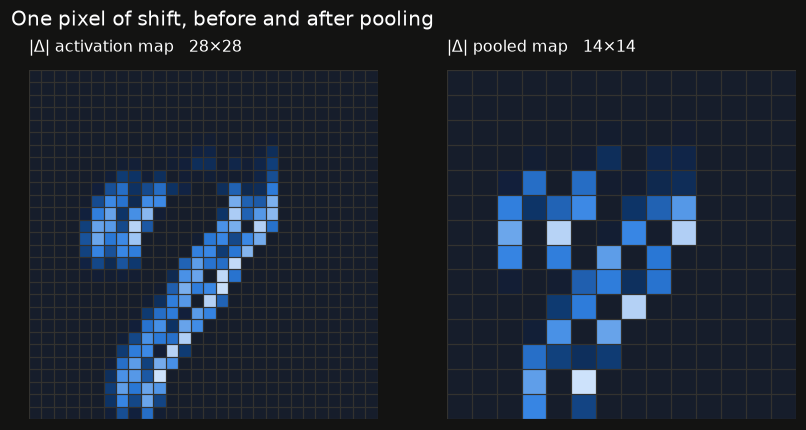

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(7.6, 3.8))
diff_act = np.abs(act_o[0] - act_s[0])
diff_pool = np.abs(pool_o[0] - pool_s[0])
shared = style.magnitude_norm(np.concatenate([diff_act.ravel(), diff_pool.ravel()]),
                              robust=False)

panels.draw_matrix(axes[0], diff_act, mode="magnitude", norm=shared,
                   title=f"|Δ| {text.t('activation_map').lower()}   28×28",
                   title_fontsize=10.5)
panels.draw_matrix(axes[1], diff_pool, mode="magnitude", norm=shared,
                   title=f"|Δ| {text.t('pooled_map').lower()}   14×14",
                   title_fontsize=10.5)

fig.suptitle(text.t("shift_title"), x=0.02, ha="left")
plt.show()

## 7. The second layer reads features, not pixels

Layer 2's input is not an image: it is four maps of *where each orientation
was found*. A $5 \times 5$ kernel there has shape $(4, 5, 5)$ — a spatial mask
per input channel — so a single unit can ask for one feature **here** and a
different feature **there**.

That is what "features of features" means concretely, and it is worth spelling
out with hand-built examples. Four units, each a set of four masks:

| Unit | Asks for |
|---|---|
| `ink` | any orientation, anywhere nearby — a stroke-energy detector |
| `corner` | vertical-edge energy to the **right**, horizontal-edge energy **above** |
| `diagonal` | either diagonal orientation nearby |
| `flanks` | vertical-edge energy on **both** sides, ignoring the middle |

The masks are non-negative and the whole kernel sums to one, so every unit
outputs a weighted average of layer-1 energies and the four are directly
comparable.

In [13]:
r = np.arange(5) - 2
U, V = np.meshgrid(r, r, indexing="ij")

BLOB = np.exp(-(U ** 2 + V ** 2) / (2 * 1.4 ** 2))   # nearby, centre-weighted
TOP = (U < 0).astype(np.float64)                     # the rows above the centre
RIGHT = (V > 0).astype(np.float64)                   # the columns right of centre
FLANKS = (np.abs(V) == 2).astype(np.float64)         # left and right edges only
ZERO = np.zeros((5, 5))


def unit(*masks):
    """One layer-2 kernel: a 5×5 mask per input channel, summing to 1 overall."""
    kernel = np.stack(masks).astype(np.float32)
    return kernel / kernel.sum()


# Channel order follows ANGLES: 0 reads vertical edges, 2 reads horizontal ones.
UNITS = {
    "ink": unit(BLOB, BLOB, BLOB, BLOB),
    "corner": unit(RIGHT, ZERO, TOP, ZERO),
    "diagonal": unit(ZERO, BLOB, ZERO, BLOB),
    "flanks": unit(FLANKS, ZERO, ZERO, ZERO),
}

conv2 = Conv2D(4, 4, kernel_size=5, padding=2, seed=1)
conv2.W = np.stack(list(UNITS.values()))
conv2.b = np.zeros(4, dtype=np.float32)

unbiased = conv2.forward(pool1)
print(f"{pool1.shape[1:]} → {unbiased.shape[1:]}")
for name, channel in zip(UNITS, unbiased[0]):
    print(f"  {name:9s} max {channel.max():.3f}")

(4, 14, 14) → (4, 14, 14)
  ink       max 0.354
  corner    max 0.585
  diagonal  max 0.358
  flanks    max 0.541


### The bias is the unit's threshold

With a bias of zero these units are useless: a weighted average of
non-negative energies is positive almost everywhere, so every unit fires
almost everywhere and distinguishes nothing.

The bias fixes that, and it is the clearest way to see what a bias *is*. It
subtracts a constant before the ReLU, so the unit only survives the gate where
its weighted sum clears a threshold. Raise the threshold and the unit becomes
progressively more selective — until it clears the largest response in the
image and the unit is dead, outputting zero for every input, receiving no
gradient, and never recovering. That failure mode is notebook 08's subject;
here it is one panel to the right of a working unit.

All four panels share one colour scale, taken from the unthresholded map.
Given their own scales, the nearly-dead panel would render as vividly as the
first and the figure would say the opposite of what it means. Sharing the
scale also makes visible that the surviving response *dims* as well as
narrows: only the threshold moves here, whereas a trained unit raises its
weights alongside its bias and keeps its output strong.

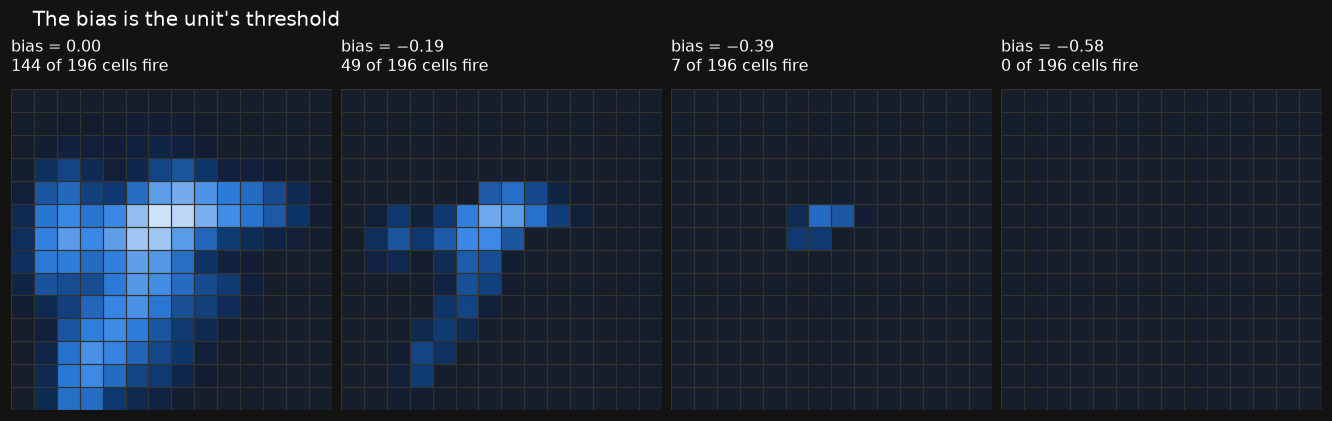

In [14]:
corner = unbiased[0, 1]
ceiling = float(corner.max())
shared = style.magnitude_norm(corner, robust=False)

fig, axes = plt.subplots(1, 4, figsize=(12, 3.9))
for ax, fraction in zip(axes, (0.0, 0.33, 0.66, 1.0)):
    bias = -fraction * ceiling
    fired = np.maximum(corner + bias, 0.0)
    panels.draw_matrix(
        ax, fired, mode="magnitude", norm=shared,
        title=f"{text.t('bias_label', v=text.num(bias, 2))}\n"
              f"{text.t('active_cells', n=int((fired > 0).sum()), m=fired.size)}",
        title_fontsize=10.5,
    )

fig.suptitle(text.t("threshold_title"), x=0.02, ha="left")
fig.savefig(results.output_path("threshold.png", notebook=NOTEBOOK), dpi=140)
plt.show()

We set each layer-2 bias so that the unit fires in the top quarter of
positions. It is a design choice, made by looking at the data, and it stands
in for what gradient descent would otherwise find — with the difference that
training tunes the biases *and* the masks together, against a loss, rather
than against our sense of what looks selective.

In [15]:
conv2.b = -np.percentile(unbiased[0], 75, axis=(1, 2)).astype(np.float32)
pre2 = conv2.forward(pool1)
act2 = ReLU().forward(pre2)

print("bias      ", np.round(conv2.b, 3))
for name, channel in zip(UNITS, act2[0]):
    print(f"  {name:9s} fires at {int((channel > 0).sum()):3d} of {channel.size} positions")

bias       [-0.193 -0.192 -0.186 -0.192]
  ink       fires at  49 of 196 positions
  corner    fires at  49 of 196 positions
  diagonal  fires at  49 of 196 positions
  flanks    fires at  49 of 196 positions


## 8. The whole stack

Six layers, assembled from the objects we built above. `Sequential` keeps
every intermediate result in `activations` — the input first, then one entry
per layer — which is what the animation draws. A framework discards those the
moment the forward pass ends; here they are the product.

The assertions are not decoration. They check that the container is doing
exactly what we did by hand, cell by cell, in the sections above.

In [16]:
net = Sequential(conv1, ReLU(), MaxPool2D(2), conv2, ReLU(), MaxPool2D(2))
out = net.forward(x)

for label, shape in net.trace():
    print(f"{label:10s} {'×'.join(str(d) for d in shape[1:])}")

assert np.allclose(net.activations[3], pool1)      # after the first pooling
assert np.allclose(net.activations[5], act2)       # after the second ReLU

input      1×28×28
Conv2D     4×28×28
ReLU       4×28×28
MaxPool2D  4×14×14
Conv2D     4×14×14
ReLU       4×14×14
MaxPool2D  4×7×7


Read the ladder: $1 \times 28 \times 28 \rightarrow 4 \times 28 \times 28
\rightarrow 4 \times 14 \times 14 \rightarrow 4 \times 7 \times 7$. Channels
go up, resolution comes down. That trade is the shape of nearly every
convolutional network ever shipped: spatial detail is progressively traded for
a larger number of increasingly specific features.

### The animation

Seven columns, one per stage, revealed left to right one channel at a time.
Each column carries its tensor shape; each arrow carries the operation that
produced the column to its right.

Rendering choices that matter here:

- **Each stage keeps one colour scale, fixed for the whole animation and
  shared across that stage's four channels.** Scales differ *between* stages
  because the quantities differ — a signed pre-activation and an unsigned
  post-ReLU magnitude are not the same thing and must not share a ramp.
- **Every axis is created on every frame**, including for stages not yet
  revealed, and hidden rather than skipped. If the layout depended on how far
  the reveal had got, the panels would shift as the pipeline filled.
- **The encoding changes down the pipeline**: greyscale for the input,
  diverging for the two pre-activations, sequential for everything after a
  ReLU. Three ramps in one frame is the reason the palette needs headroom.

Rendering takes about half a minute for 28 frames; the four animations in this
notebook together take under three.

In [17]:
STAGES = [
    # activation index, encoding, caption key, operation that produced it
    (0, "pixels",    "stack_cap_input", None),
    (1, "signed",    "stack_cap_conv1", ("conv_op", 5)),
    (2, "magnitude", "stack_cap_relu1", ("relu_op", None)),
    (3, "magnitude", "stack_cap_pool1", ("pool_op", 2)),
    (4, "signed",    "stack_cap_conv2", ("conv_op", 5)),
    (5, "magnitude", "stack_cap_relu2", ("relu_op", None)),
    (6, "magnitude", "stack_cap_pool2", ("pool_op", 2)),
]

ACT = [a[0] for a in net.activations]        # drop the batch axis
# Keyed by activation index, not by position in STAGES, so the portrait cut
# below can look up the same scale for the subset of stages it shows.
NORM_FOR = {
    index: (style.signed_norm if mode == "signed" else style.magnitude_norm)(
        ACT[index], robust=False
    )
    for index, mode, _, _ in STAGES
}

PER_STAGE = 4                                 # frames per stage: one per channel
N_STACK = len(STAGES) * PER_STAGE
STOP, SBOTTOM = 0.775, 0.145


def op_label(operation):
    key, size = operation
    return text.t(key, k=size) if size else text.t(key)


def draw_stack(fig, frame):
    stage, step = divmod(frame, PER_STAGE)

    gs = GridSpec(4, len(STAGES), figure=fig, left=0.028, right=0.988,
                  top=STOP, bottom=SBOTTOM, wspace=0.26, hspace=0.16)

    # Lay out every column on every frame, revealed or not: a layout that
    # depended on the frame would let the panels drift as the pipeline fills.
    columns = []
    for s, (index, *_) in enumerate(STAGES):
        if ACT[index].shape[0] == 1:
            columns.append([fig.add_subplot(gs[1:3, s])])       # a single centred panel
        else:
            columns.append([fig.add_subplot(gs[row, s]) for row in range(4)])

    for s, (index, mode, _, operation) in enumerate(STAGES):
        maps, axes = ACT[index], columns[s]

        if s > stage:
            for ax in axes:
                ax.set_visible(False)
            continue

        shown = maps.shape[0] if s < stage else min(step + 1, maps.shape[0])
        panels.draw_maps(axes[:shown], maps[:shown], mode=mode, norm=NORM_FOR[index])
        for ax in axes[shown:]:
            ax.set_visible(False)

        box = axes[0].get_position()
        fig.text((box.x0 + box.x1) / 2, STOP + 0.026,
                 "×".join(str(d) for d in maps.shape),
                 ha="center", va="bottom", fontsize=9.5, color=style.INK_SECONDARY)

        if s:
            panels.arrow_between(fig, columns[s - 1][0], axes[0], op_label(operation),
                                 y=(STOP + SBOTTOM) / 2)

    panels.frame_header(fig, text.t("stack_title"), text.t("stack_subtitle"))
    panels.caption(fig, text.t(STAGES[stage][2]))
    panels.progress_bar(fig, (frame + 1) / N_STACK)


# A beat on the last frame of each stage, so a completed column can be read
# before the next one starts appearing.
stack_holds = {PER_STAGE * s + PER_STAGE - 1: 0.55 for s in range(len(STAGES))}

animate.animate(
    draw_stack,
    n_frames=N_STACK,
    path=results.output_path("stack_forward.gif", notebook=NOTEBOOK),
    figsize=(12.6, 6.0),
    colors=128,
    durations=animate.hold_at(N_STACK, fps=6, holds=stack_holds, first=0.9, last=2.2),
)

02_stack_forward:   0%|          | 0/28 [00:00<?, ?frame/s]

PosixPath('/Users/usuario/Desktop/howAIworks/results/02_stack_forward.gif')

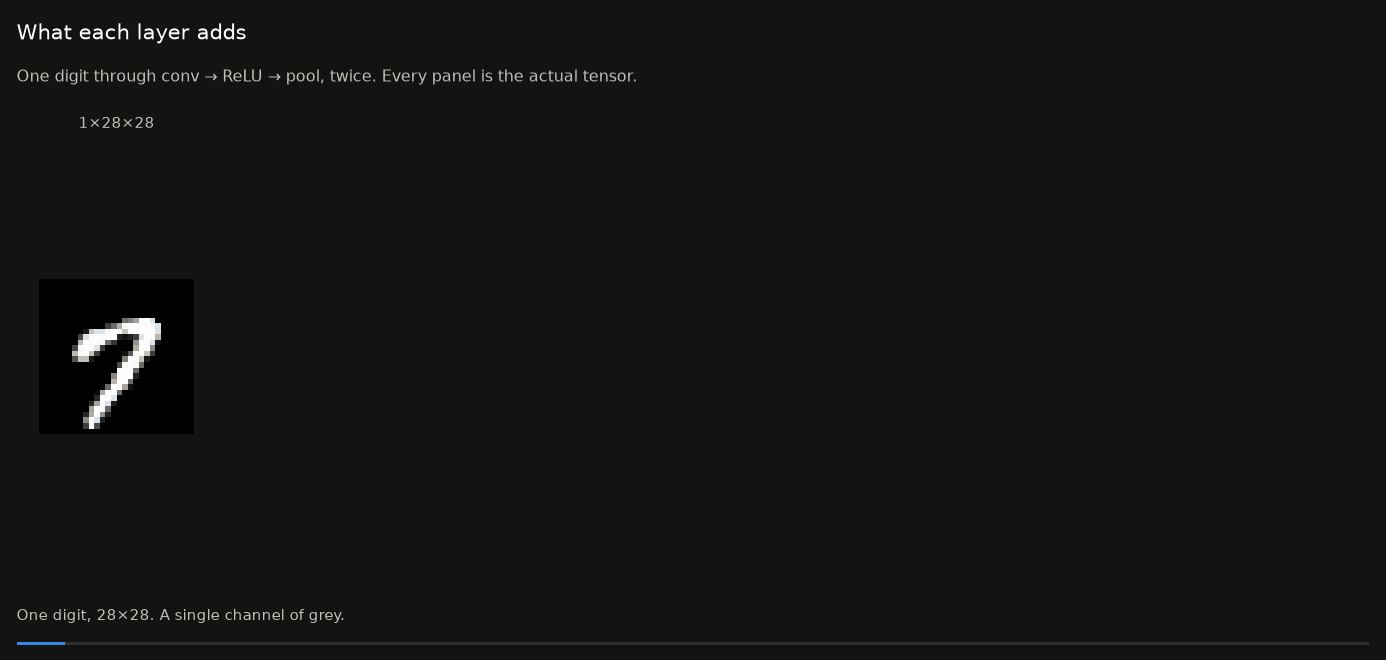

In [18]:
display(Image(filename=str(results.output_path("02_stack_forward.gif"))))

The fifth column is the one to look at twice. It is layer 2's pre-activation,
and it is mostly blue — below threshold — with red only where a unit's
combination is actually present. The column after it is the same tensor with
the negative half removed. That pair is the entire mechanism of a deep
network: *propose many combinations, keep the few that clear a threshold.*

## 9. Receptive fields: why depth buys context

A unit's **receptive field** is the patch of the *input* that can still change
its value. It is the quantitative form of "deeper layers see more".

Walking backwards through the stack, one layer at a time, output $i$ reads
inputs $i s - p$ through $i s - p + k - 1$. Composing that from the deepest
layer outwards gives exact integer bounds — `trace_receptive_field` does
precisely this, and `receptive_field` reports the size and the spacing between
neighbouring units' patches.

The spacing is the part that surprises people. It is the product of the
strides, so after two $2 \times 2$ poolings a $5 \times 5$ kernel reaches
across 16 input pixels rather than 5. Depth widens the view faster than kernel
size does, and it is cheaper.

In [19]:
STAGE_NAMES = [text.t("input"), text.t("conv_op", k=5), text.t("relu_op"),
               text.t("pool_op", k=2), text.t("conv_op", k=5), text.t("relu_op"),
               text.t("pool_op", k=2)]
sizes = [receptive_field(net, depth)[0] for depth in range(len(net) + 1)]
jumps = [receptive_field(net, depth)[1] for depth in range(len(net) + 1)]

for name, size, jump in zip(STAGE_NAMES, sizes, jumps):
    print(f"{name:15s} sees {size:2d}×{size:<2d} pixels   ·   {jump} px apart")

Input           sees  1×1  pixels   ·   1 px apart
conv 5×5        sees  5×5  pixels   ·   1 px apart
ReLU            sees  5×5  pixels   ·   1 px apart
max-pool 2×2    sees  6×6  pixels   ·   2 px apart
conv 5×5        sees 14×14 pixels   ·   2 px apart
ReLU            sees 14×14 pixels   ·   2 px apart
max-pool 2×2    sees 16×16 pixels   ·   4 px apart


The figure below draws the boxes on the digit itself. For each depth we take
the unit whose receptive field sits nearest the middle of the image, so the
boxes nest and the growth is legible; a unit at the edge of a padded layer
reads partly into the zero padding, which is why
`trace_receptive_field` is allowed to return negative coordinates.

The four depths carry four categorical hues, and the same hue marks the same
depth in the chart beside it — which is what lets the boxes go unlabelled,
since four numbers crowded onto four nested boxes are unreadable. This is the
one place in the series where categorical colour is applied to something other
than a time series; the rule it obeys is the important one: **a colour means
one entity in both panels.**

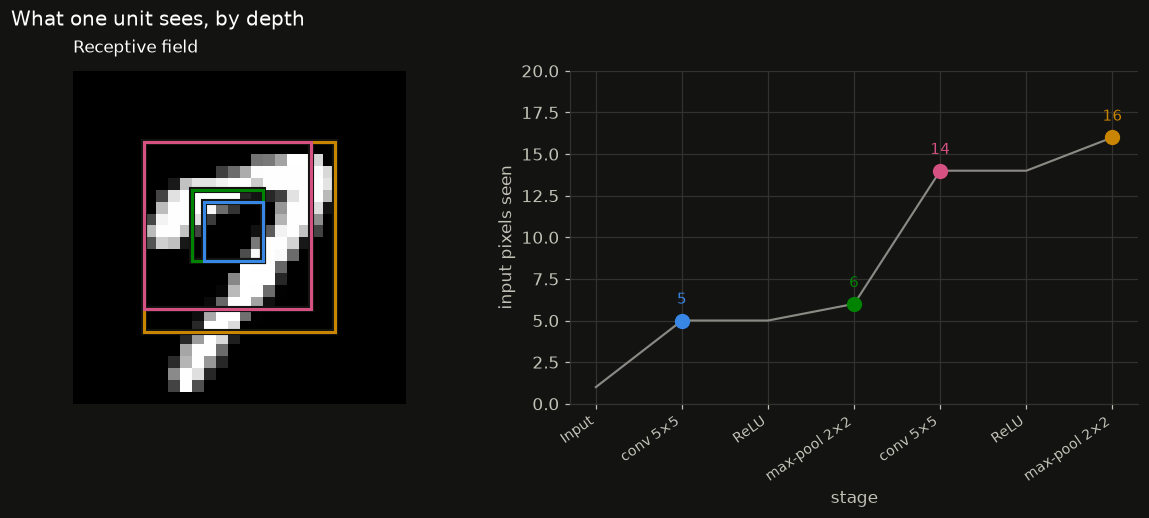

In [20]:
DEPTHS = (1, 3, 4, 6)
COLOURS = [style.CATEGORICAL[i] for i in range(len(DEPTHS))]


def centred_unit(depth):
    """Index of the unit at `depth` whose receptive field sits nearest the middle."""
    width = net.activations[depth].shape[-1]
    middle = (digit.shape[0] - 1) / 2

    def offset(index):
        top, _, size = trace_receptive_field(net, index, index, depth)
        return abs(top + (size - 1) / 2 - middle)

    return min(range(width), key=offset)


fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.6), width_ratios=[1, 1.15])

# grid=False here: the boxes are the message, and 28 rows of hairlines
# underneath them turns the panel into noise.
panels.draw_matrix(axes[0], digit, mode="pixels", title=text.t("receptive_field"),
                   title_fontsize=11, grid=False)
# Largest box first: highlight_window lays a surface-coloured halo under its
# stroke, which would otherwise erase the smaller boxes drawn before it.
for depth, colour in reversed(list(zip(DEPTHS, COLOURS))):
    index = centred_unit(depth)
    top, left, size = trace_receptive_field(net, index, index, depth)
    panels.highlight_window(axes[0], top, left, size, color=colour, linewidth=2.0)

axes[1].plot(range(len(sizes)), sizes, color=style.INK_MUTED, linewidth=1.4, zorder=1)
for depth, colour in zip(DEPTHS, COLOURS):
    axes[1].plot([depth], [sizes[depth]], "o", color=colour, markersize=9, zorder=2)
    axes[1].annotate(f"{sizes[depth]}", (depth, sizes[depth]),
                     textcoords="offset points", xytext=(0, 11), ha="center",
                     fontsize=9.5, color=colour)

axes[1].set_xticks(range(len(sizes)))
axes[1].set_xticklabels(STAGE_NAMES, rotation=35, ha="right", fontsize=9)
axes[1].set_ylim(0, 20)
axes[1].set_xlabel(text.t("rf_stage"))
axes[1].set_ylabel(text.t("rf_pixels"))

fig.suptitle(text.t("rf_title"), x=0.02, ha="left")
fig.savefig(results.output_path("receptive_field.png", notebook=NOTEBOOK), dpi=140)
plt.show()

Sixteen pixels of a 28-pixel digit, from two $5 \times 5$ kernels. Every cell
of the final $7 \times 7$ map summarises more than half the width of the image,
which is why a classifier stacked on top of it can be asked about the digit as
a whole rather than about a corner of it.

Note also that the ReLU rows are flat: a pointwise operation reads one input
per output and cannot widen anything. Only kernels and strides move that
number.

## 10. A second cut, for a narrow canvas

Both animations above are laid out for a wide canvas read at leisure. Neither
survives being scaled down: the seven-column pipeline leaves each panel a few
dozen pixels across, and the pooling sweep becomes a 2.7:1 letterbox whose
annotated cells are unreadable at any size that fits a narrow column.

The fix is not a smaller copy of the same figure. It is a **different layout on
a different canvas**: 4:5 portrait at 1080x1350, roughly double the type, and a
title short enough to read at a glance.

What each cut drops is the substance of it. The pipeline drops the two
pre-activation stages and keeps pixels, edges, combinations, summary — the
argument reduced to what four panels can carry. The sweep keeps all three of
its panels and stacks them instead of laying them out across.

`panels.arrow_between` reads its direction from where the panels actually sit,
so the same call that drew left-to-right arrows above draws downward ones here.

`cnnviz.formats` holds the canvas presets, and `mp4=True` writes an H.264 file
beside the GIF. That is not a cosmetic alternative: GIF is limited to a 256
colour palette and stores frames whole, so the video is both more faithful on
the ramps and several times smaller for the same animation.

In [21]:
CANVAS = formats.FEED_PORTRAIT

FEED_STAGES = [
    # activation index, encoding, caption key, arrow label
    (0, "pixels", "stack_cap_input", None),
    (2, "magnitude", "stack_cap_relu1",
     f"{text.t('conv_op', k=5)} + {text.t('relu_op')}"),
    (5, "magnitude", "stack_cap_relu2",
     f"{text.t('pool_op', k=2)} + {text.t('conv_op', k=5)} + {text.t('relu_op')}"),
    (6, "magnitude", "stack_cap_pool2", text.t("pool_op", k=2)),
]
FEED_ROWS = [(0.878, 0.762), (0.726, 0.578), (0.542, 0.394), (0.358, 0.210)]
N_FEED = len(FEED_STAGES) * PER_STAGE


def draw_feed(fig, frame):
    stage, step = divmod(frame, PER_STAGE)

    rows = []
    for (index, *_), (top, bottom) in zip(FEED_STAGES, FEED_ROWS):
        channels = ACT[index].shape[0]
        if channels == 1:
            gs = GridSpec(1, 1, figure=fig, left=0.40, right=0.60,
                          top=top, bottom=bottom)
        else:
            gs = GridSpec(1, channels, figure=fig, left=0.06, right=0.94,
                          top=top, bottom=bottom, wspace=0.10)
        rows.append([fig.add_subplot(gs[0, c]) for c in range(channels)])

    for s, (index, mode, _, arrow) in enumerate(FEED_STAGES):
        maps, axes = ACT[index], rows[s]

        if s > stage:
            for ax in axes:
                ax.set_visible(False)
            continue

        shown = maps.shape[0] if s < stage else min(step + 1, maps.shape[0])
        panels.draw_maps(axes[:shown], maps[:shown], mode=mode, norm=NORM_FOR[index])
        for ax in axes[shown:]:
            ax.set_visible(False)

        if s:
            # Operation on one line, resulting shape on the next: as one line,
            # the middle transition's three operations overran the canvas.
            panels.arrow_between(
                fig, rows[s - 1][0], axes[0],
                f"{arrow}\n→ {'×'.join(str(d) for d in maps.shape)}",
                x=0.5, fontsize=CANVAS.pt(7.0),
            )

    fig.text(0.06, 0.972, text.t("stack_title_short"), ha="left", va="top",
             fontsize=CANVAS.pt(13.5), color=style.INK_PRIMARY)
    fig.text(0.06, 0.932, text.t("stack_subtitle_short"), ha="left", va="top",
             fontsize=CANVAS.pt(8.5), color=style.INK_SECONDARY)

    fig.text(0.5, 0.112, text.t(FEED_STAGES[stage][2]), ha="center", va="bottom",
             fontsize=CANVAS.pt(8.0), color=style.INK_SECONDARY)
    panels.progress_bar(fig, (frame + 1) / N_FEED, y=0.062, x=0.06, width=0.88,
                        height=0.005)


feed_holds = {PER_STAGE * s + PER_STAGE - 1: 0.7 for s in range(len(FEED_STAGES))}

animate.animate(
    draw_feed,
    n_frames=N_FEED,
    path=results.output_path("stack_forward_feed.gif", notebook=NOTEBOOK),
    figsize=CANVAS.figsize,
    colors=160,
    mp4=True,
    durations=animate.hold_at(N_FEED, fps=6, holds=feed_holds, first=0.9, last=1.8),
)

02_stack_forward_feed:   0%|          | 0/16 [00:00<?, ?frame/s]

PosixPath('/Users/usuario/Desktop/howAIworks/results/02_stack_forward_feed.gif')

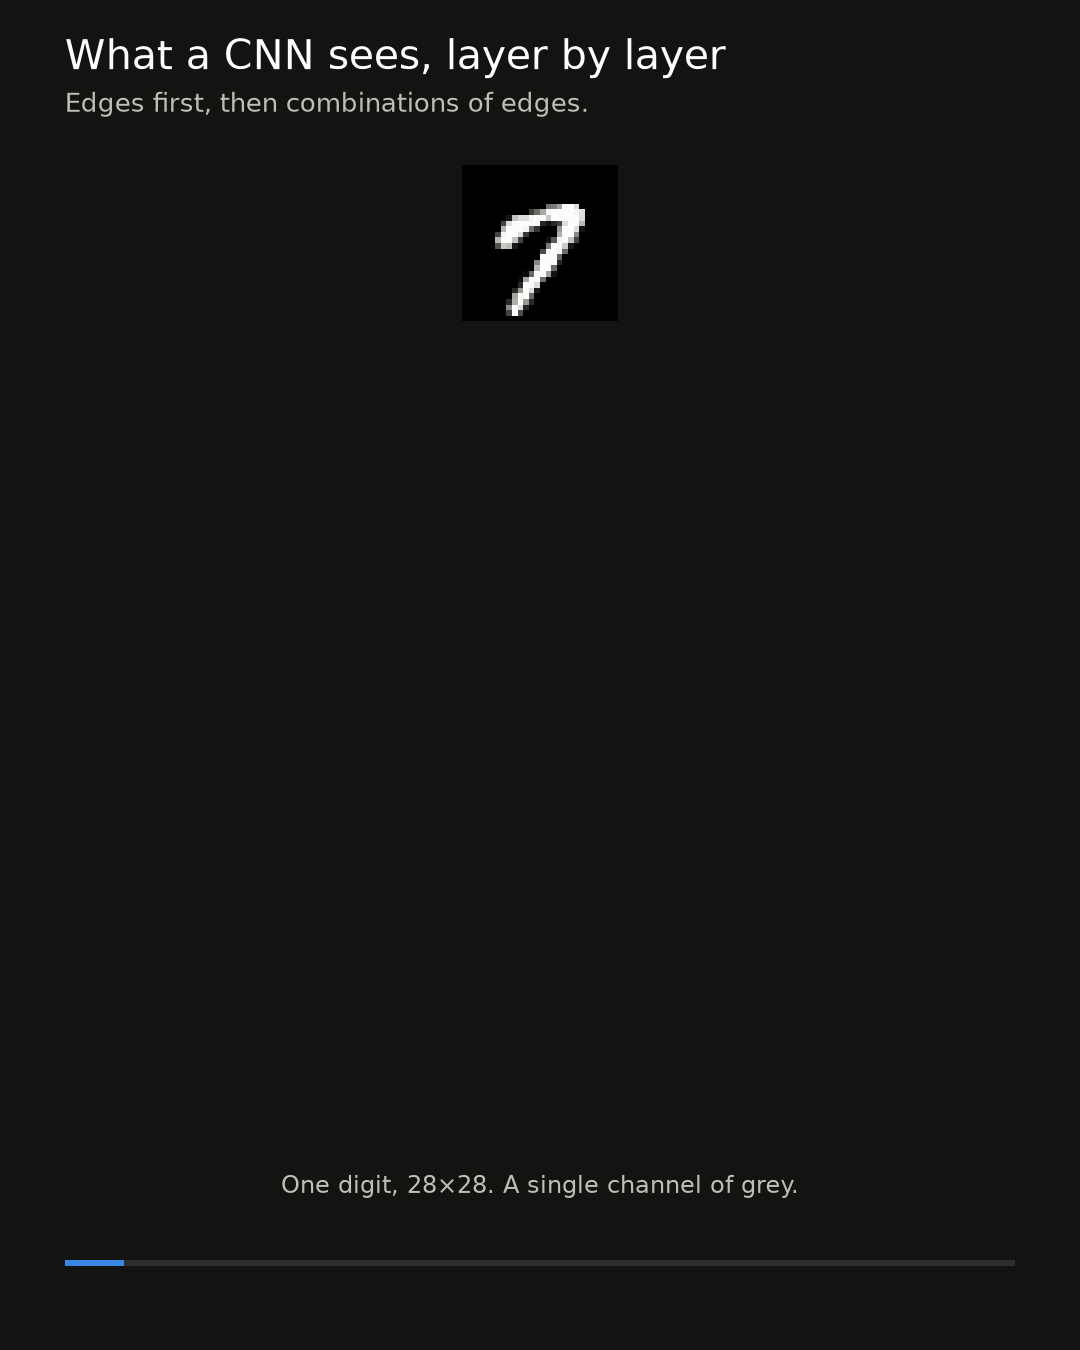

In [22]:
display(Image(filename=str(results.output_path("02_stack_forward_feed.gif"))))

### The pooling sweep, portrait

The same three panels as section 6, stacked instead of laid out across, with
the window enlarged, because at this size the four annotated numbers are the
whole point of the frame.

One thing carries over unchanged and matters more here than in the wide layout:
the two map panels still share **one colour scale fixed over the whole sweep**.
Stripped of the surrounding prose, a panel is the only thing arguing for its own
reading, and one that rescaled itself per frame would argue for the wrong one
with nothing on screen to correct it.

In [23]:
FTOP, FBOTTOM = 0.500, 0.268


def draw_pool_feed(fig, k):
    row, col = POSITIONS[k]
    window = crop[row * 2:row * 2 + 2, col * 2:col * 2 + 2]
    winner = np.unravel_index(np.argmax(window), window.shape)

    gs_map = GridSpec(1, 1, figure=fig, left=0.17, right=0.83,
                      top=0.845, bottom=0.545)
    ax_in = fig.add_subplot(gs_map[0, 0])

    gs_pair = GridSpec(1, 2, figure=fig, width_ratios=[0.62, 1.0],
                       left=0.13, right=0.87, top=FTOP, bottom=FBOTTOM, wspace=0.40)
    ax_win = fig.add_subplot(gs_pair[0, 0])
    ax_out = fig.add_subplot(gs_pair[0, 1])

    panels.draw_matrix(ax_in, crop, mode="magnitude", norm=NORM_ACT,
                       title=f"{text.t('activation_map')}   12×12",
                       title_fontsize=CANVAS.pt(10))
    panels.highlight_window(ax_in, row * 2, col * 2, size=2, linewidth=3.0)

    panels.draw_matrix(ax_win, window, mode="magnitude", norm=NORM_ACT, annotate=True,
                       fontsize=CANVAS.pt(9), title=text.t("pool_window"),
                       title_fontsize=CANVAS.pt(10))
    panels.highlight_window(ax_win, winner[0], winner[1], size=1, linewidth=3.0)

    revealed = np.ma.masked_all(pooled.shape, dtype=pooled.dtype)
    revealed.flat[:k + 1] = pooled.flat[:k + 1]
    panels.draw_matrix(ax_out, revealed, mode="magnitude", norm=NORM_ACT,
                       title=f"{text.t('pooled_map')}   6×6",
                       title_fontsize=CANVAS.pt(10))
    panels.highlight_window(ax_out, row, col, size=1, linewidth=3.0)

    panels.glyph_between(fig, ax_win, ax_out, "→", y=(FTOP + FBOTTOM) / 2,
                         fontsize=CANVAS.pt(16))

    fig.text(0.5, 0.212, text.t("pool_max", v=text.num(float(window.max()), 2)),
             ha="center", va="top", fontsize=CANVAS.pt(13), color=style.INK_PRIMARY)

    fig.text(0.06, 0.972, text.t("pool_title_short"), ha="left", va="top",
             fontsize=CANVAS.pt(13.5), color=style.INK_PRIMARY)
    fig.text(0.06, 0.932, text.t("pool_subtitle_short"), ha="left", va="top",
             fontsize=CANVAS.pt(8.5), color=style.INK_SECONDARY)

    fig.text(0.5, 0.128, text.t("pool_gradient"), ha="center", va="bottom",
             fontsize=CANVAS.pt(8.0), color=style.INK_SECONDARY)
    panels.caption(fig, text.t("position_of", k=k + 1, n=len(POSITIONS)),
                   x=0.5, y=0.095, fontsize=CANVAS.pt(7.5), ha="center")
    panels.progress_bar(fig, (k + 1) / len(POSITIONS), y=0.062, x=0.06,
                        width=0.88, height=0.005)


animate.animate(
    draw_pool_feed,
    n_frames=len(POSITIONS),
    path=results.output_path("maxpool_sweep_feed.gif", notebook=NOTEBOOK),
    figsize=CANVAS.figsize,
    colors=160,
    mp4=True,
    durations=animate.hold_at(len(POSITIONS), fps=8, holds={0: 1.2, 1: 0.7, 2: 0.4},
                              first=0.8, last=1.6),
)

02_maxpool_sweep_feed:   0%|          | 0/36 [00:00<?, ?frame/s]

PosixPath('/Users/usuario/Desktop/howAIworks/results/02_maxpool_sweep_feed.gif')

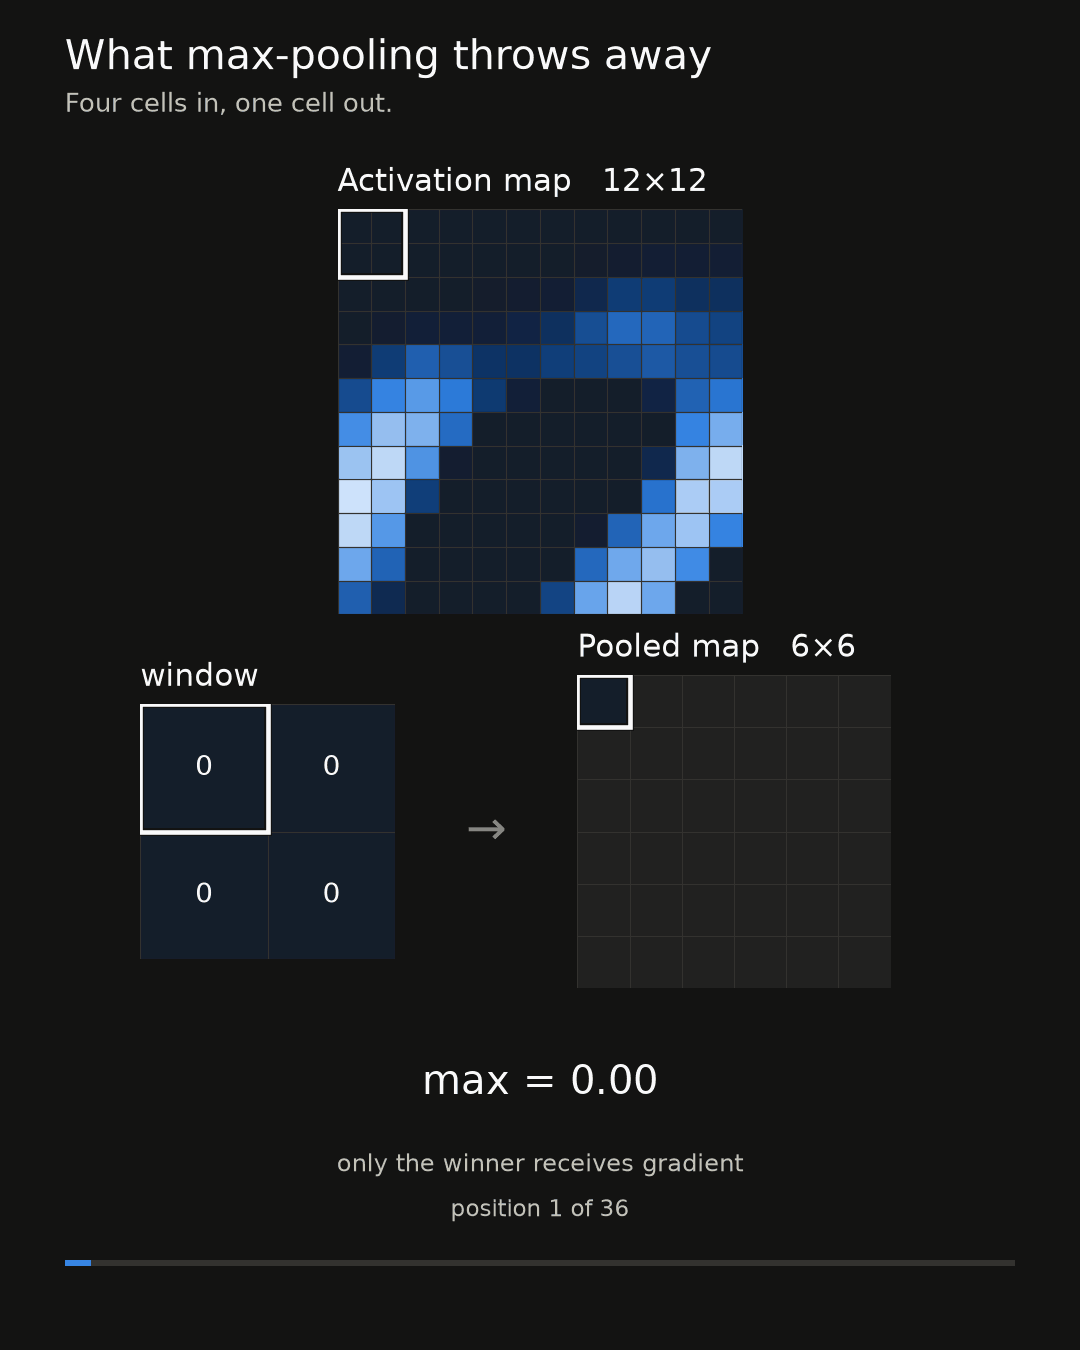

In [24]:
display(Image(filename=str(results.output_path("02_maxpool_sweep_feed.gif"))))

## 11. Refresh the results index

In [25]:
results.write_index()

for item in results.list_results("02_*"):
    print(f"{item.name:34s} {item.stat().st_size / 1e6:6.2f} MB")

02_linear_collapse.png               0.08 MB
02_maxpool_sweep.gif                 0.18 MB
02_maxpool_sweep_feed.gif            0.31 MB
02_maxpool_sweep_feed.mp4            0.26 MB
02_receptive_field.png               0.06 MB
02_relu_gate.png                     0.05 MB
02_stack_forward.gif                 0.09 MB
02_stack_forward_feed.gif            0.09 MB
02_stack_forward_feed.mp4            0.14 MB
02_threshold.png                     0.03 MB


## 12. What we have, and what is missing

Four things are now established, each of them measured rather than asserted:

1. **Stacked convolutions alone collapse into one convolution.** The
   nonlinearity is not a detail; without it, depth is decoration.
2. **ReLU is a gate**, and it throws away half of every map. Its mask is the
   same mask the backward pass will use.
3. **Pooling downsamples and buys tolerance**, cutting the effect of a
   one-pixel shift by about a third — while plain subsampling buys nothing.
4. **Depth widens the receptive field faster than kernel size does.** Two
   $5 \times 5$ kernels and two poolings put 16 of 28 pixels behind every
   output cell.

And the same gap as before, now wider. Every kernel and every bias in this
notebook was **designed** — the orientations chosen, the masks drawn by hand,
the thresholds set by looking at a percentile of the data. The architecture is
real; the parameters are ours.

A trained network gets all of them from one number: how wrong its output was.
To watch that happen we need that number first, and a way to move every
parameter in the direction that shrinks it.

**Next:** `03_the_loss_landscape.ipynb` — what a loss is, what its surface
looks like over the parameters, and why following the gradient downhill works
at all.